In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\meera\OneDrive\Desktop\spotify analytics\dataset.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [9]:
df.shape

(114000, 21)

In [10]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [11]:
df['popularity'].describe()

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

In [12]:
df['track_genre'].value_counts()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

In [13]:
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
print(genre_popularity.head(10))
print("---")
print(genre_popularity.tail(10))

track_genre
pop-film     59.283
k-pop        56.896
chill        53.651
sad          52.379
grunge       49.594
indian       49.539
anime        48.772
emo          48.128
sertanejo    47.866
pop          47.576
Name: popularity, dtype: float64
---
track_genre
idm               15.766
kids              14.888
grindcore         14.625
jazz              13.628
classical         13.055
chicago-house     12.339
detroit-techno    11.174
latin              8.297
romance            3.245
iranian            2.210
Name: popularity, dtype: float64


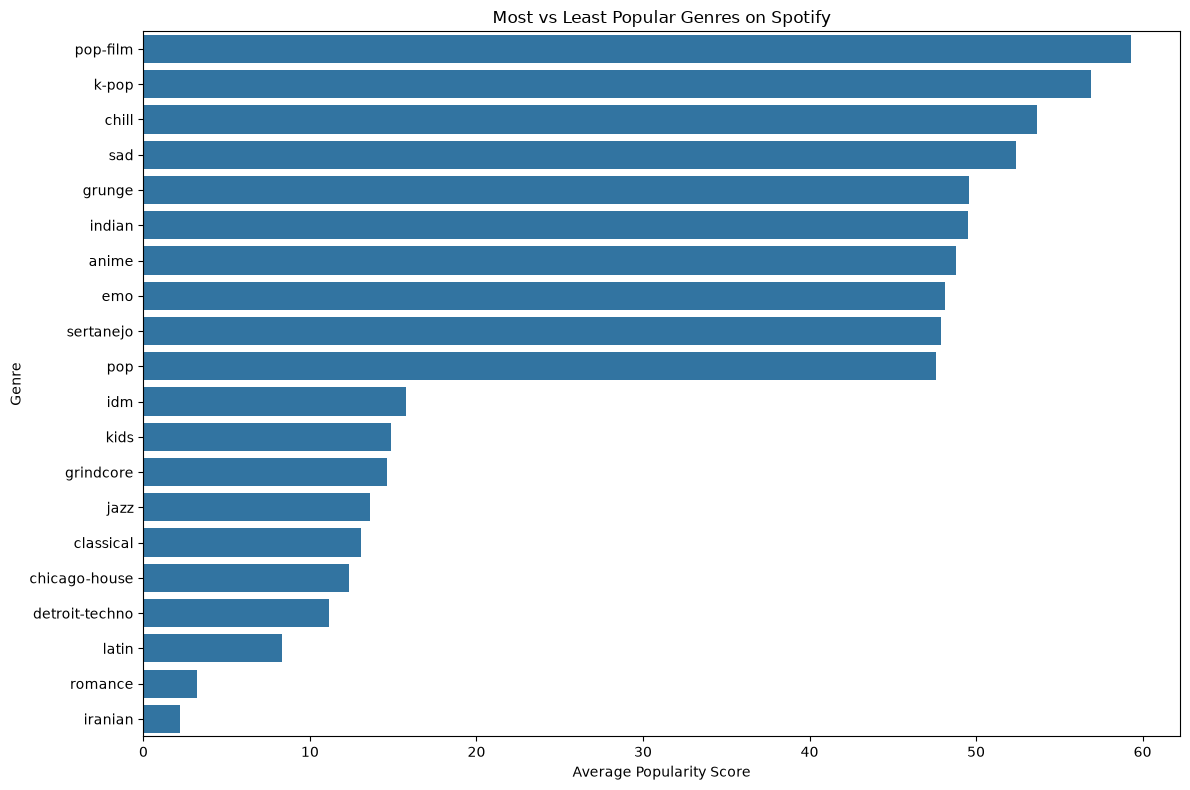

In [14]:
top_bottom = pd.concat([genre_popularity.head(10), genre_popularity.tail(10)])

plt.figure(figsize=(12, 8))
sns.barplot(x=top_bottom.values, y=top_bottom.index)
plt.title('Most vs Least Popular Genres on Spotify')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [15]:
features = ['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'speechiness']

correlation = df[features + ['popularity']].corr()['popularity'].drop('popularity').sort_values(ascending=False)

print(correlation)

danceability    0.035448
tempo           0.013205
energy          0.001056
acousticness   -0.025472
valence        -0.040534
speechiness    -0.044927
Name: popularity, dtype: float64


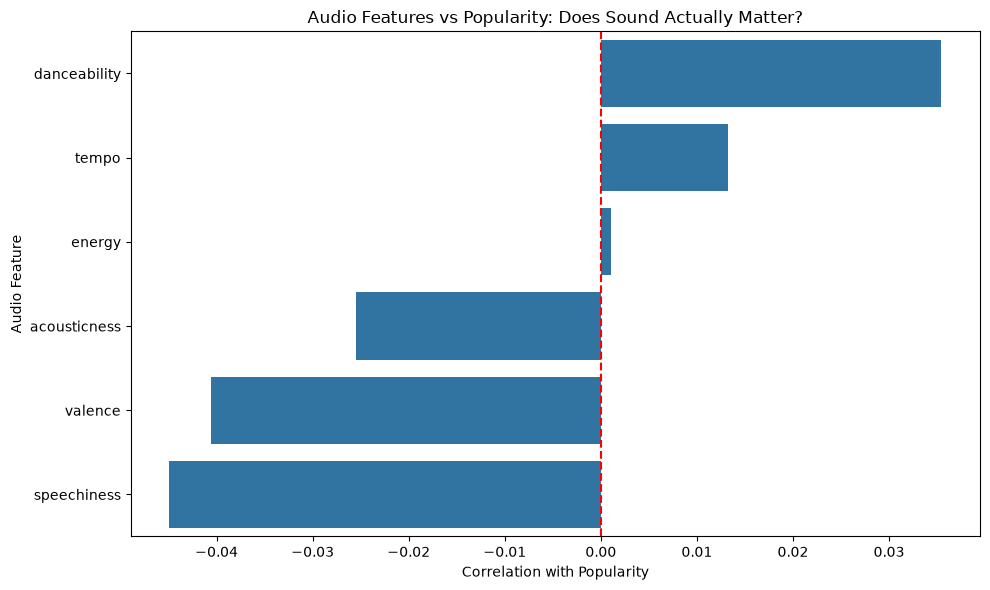

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation.values, y=correlation.index)
plt.title('Audio Features vs Popularity: Does Sound Actually Matter?')
plt.xlabel('Correlation with Popularity')
plt.ylabel('Audio Feature')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

In [17]:
artist_popularity = df.groupby('artists')['popularity'].mean().sort_values(ascending=False)
print(artist_popularity.head(10))

artists
Sam Smith;Kim Petras           100.0
Bizarrap;Quevedo                99.0
Manuel Turizo                   98.0
Bad Bunny;Chencho Corleone      97.0
Bad Bunny;Bomba Estéreo         94.5
Joji                            94.0
Beyoncé                         93.0
Rema;Selena Gomez               92.0
Harry Styles                    92.0
Rauw Alejandro;Lyanno;Brray     91.0
Name: popularity, dtype: float64


C:\Users\meera\AppData\Local\Temp\ipykernel_31332\2993614517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_popularity.values, y=genre_popularity.index, palette=colors)


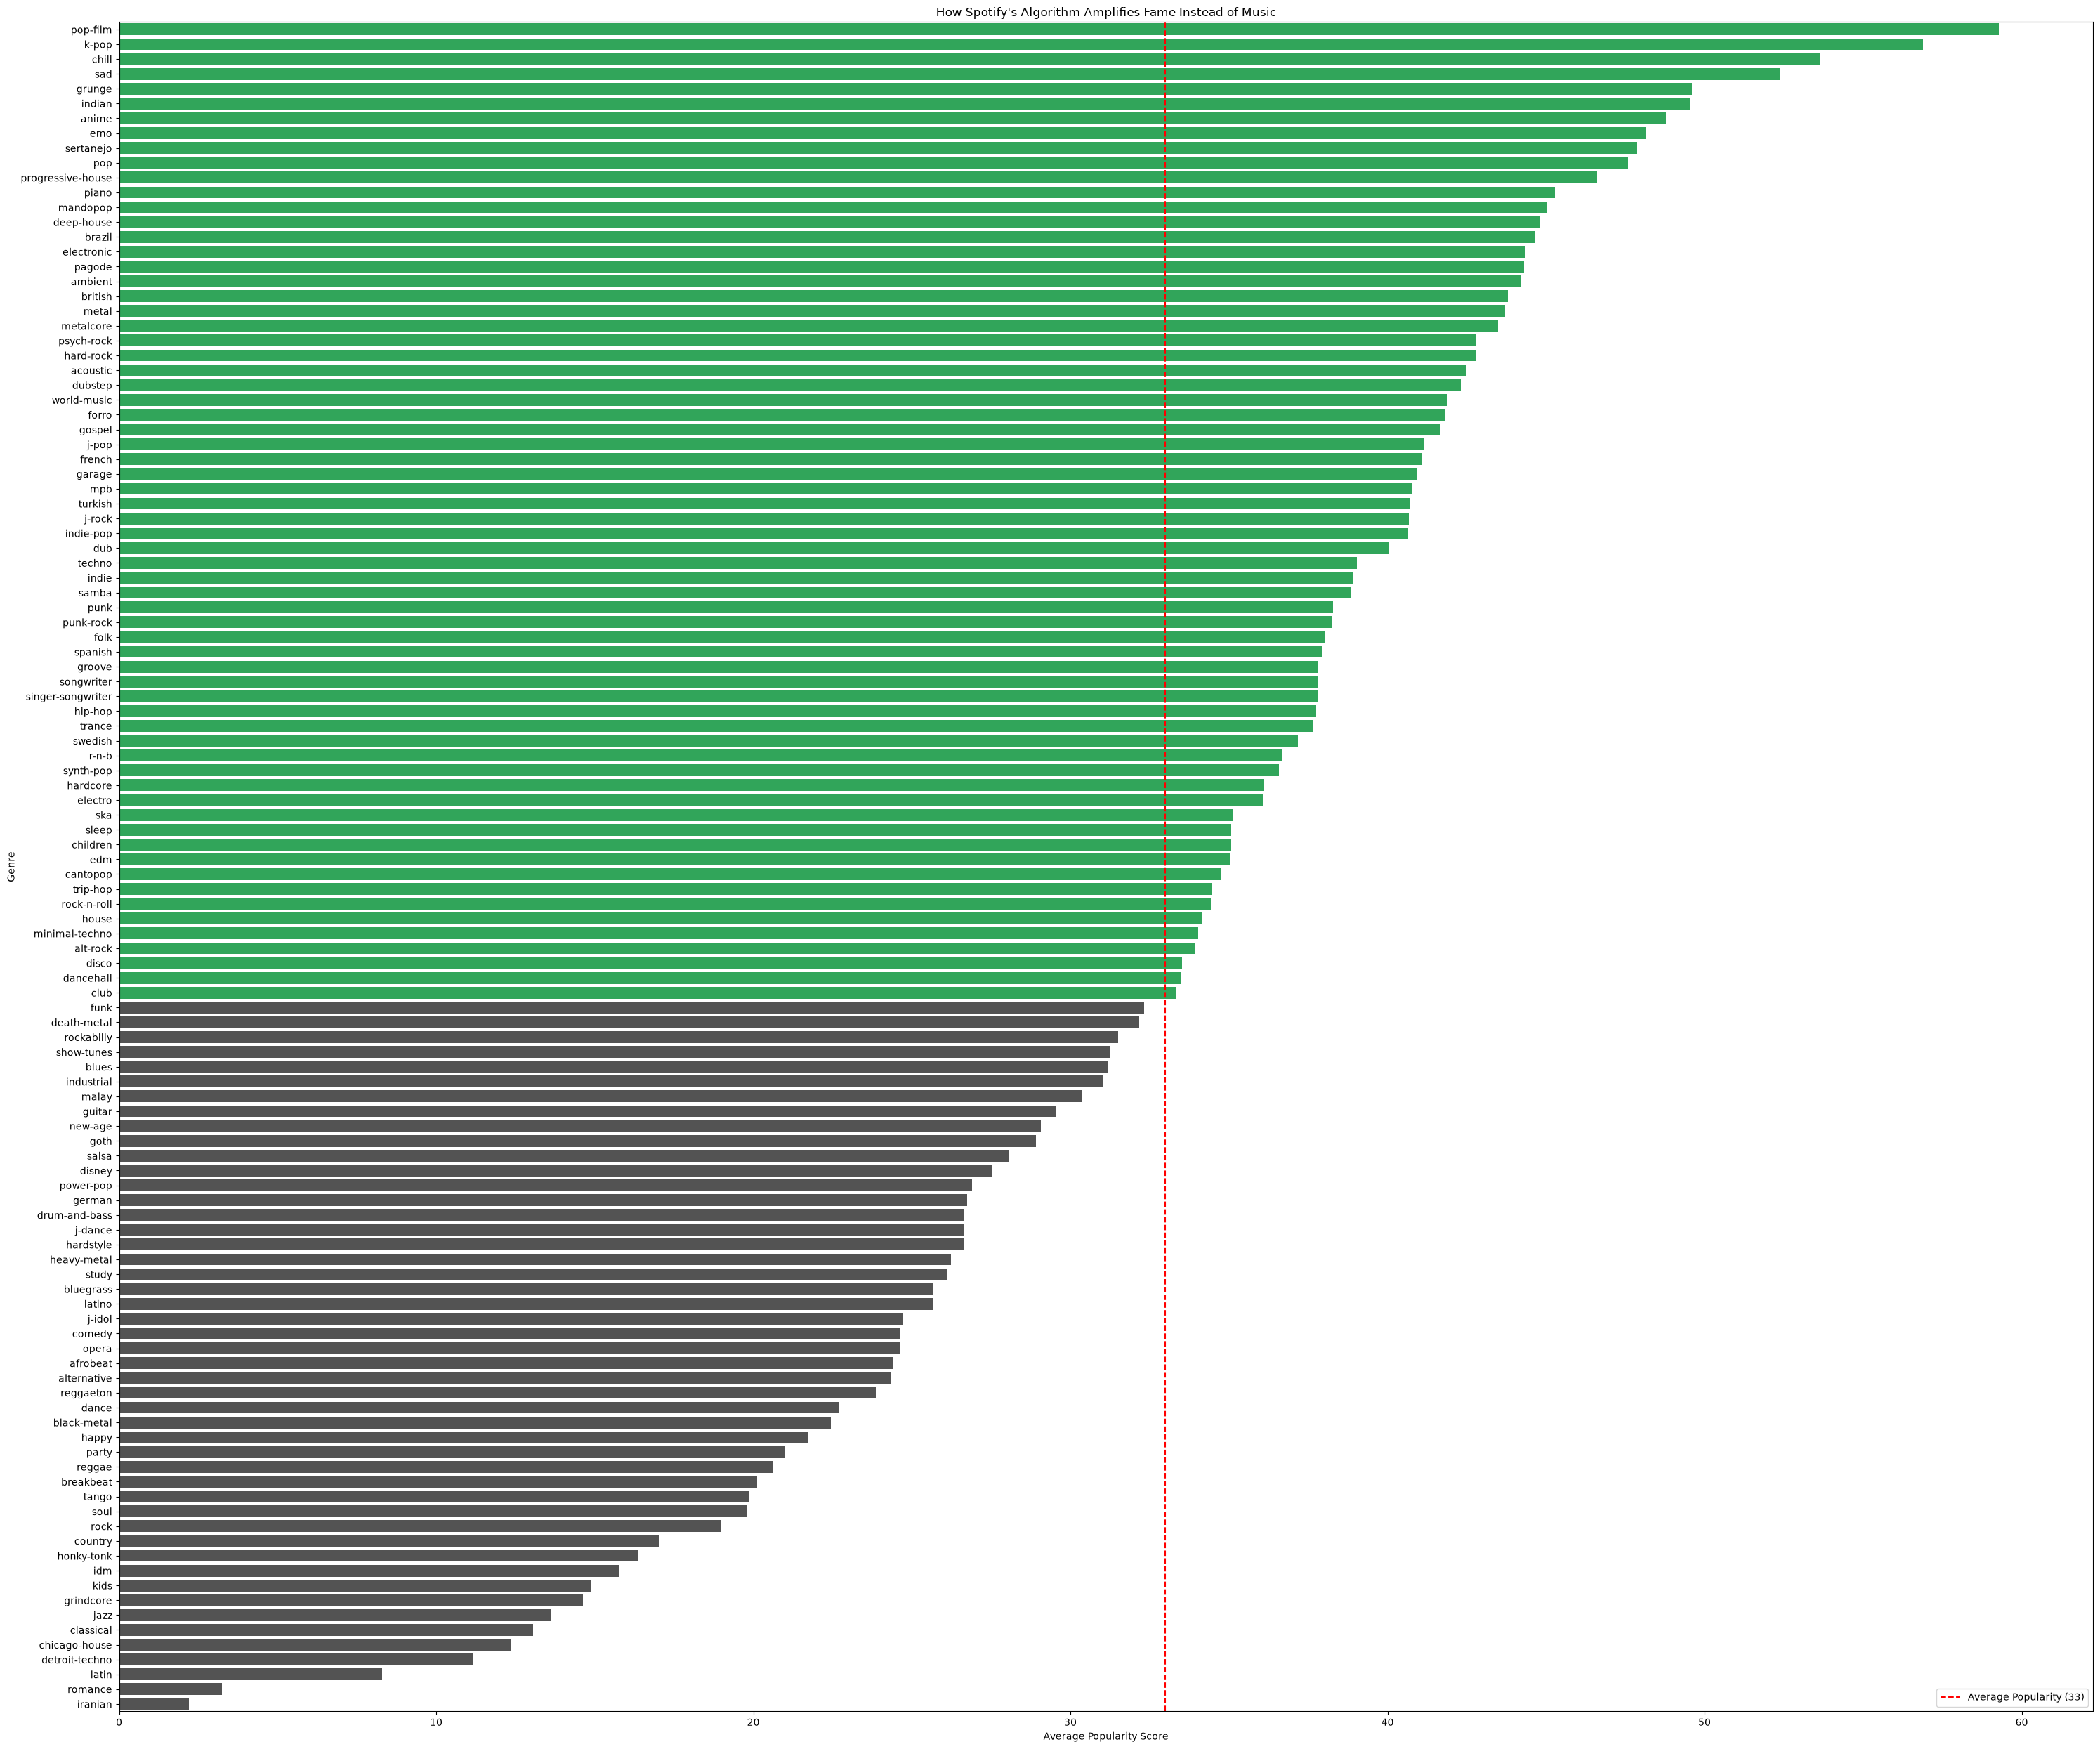

In [21]:
plt.figure(figsize=(30, 25))
colors = ['#1DB954' if x > 33 else '#535353' for x in genre_popularity.values]
sns.barplot(x=genre_popularity.values, y=genre_popularity.index, palette=colors)
plt.axvline(x=33, color='red', linestyle='--', label='Average Popularity (33)')
plt.title('How Spotify\'s Algorithm Amplifies Fame Instead of Music')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.legend()
plt.tight_layout()
plt.show()